In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
breast_cancer_data = pd.read_csv('/home/nijesh-shrestha/Downloads/breast-cancer.csv')
breast_cancer_data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


/tmp/ipykernel_11987/1395370348.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=breast_cancer_data['diagnosis'], palette='coolwarm')


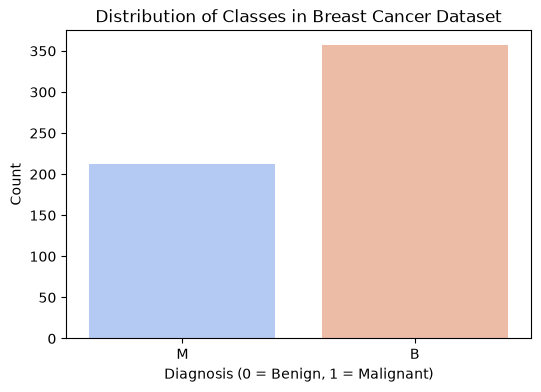

In [3]:
plt.figure(figsize=(6, 4))
sns.countplot(x=breast_cancer_data['diagnosis'], palette='coolwarm')
plt.title('Distribution of Classes in Breast Cancer Dataset')
plt.xlabel('Diagnosis (0 = Benign, 1 = Malignant)')
plt.ylabel('Count')
plt.show()

In [6]:
label_encoder = LabelEncoder()
breast_cancer_data['diagnosis'] = label_encoder.fit_transform(breast_cancer_data['diagnosis'])

In [7]:
X_bc = breast_cancer_data.drop(columns=['diagnosis'])
y_bc = breast_cancer_data['diagnosis']

In [8]:
X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(X_bc, y_bc, test_size=0.2, random_state=42)

scaler_bc = StandardScaler()
X_train_bc = scaler_bc.fit_transform(X_train_bc)
X_test_bc = scaler_bc.transform(X_test_bc)

knn_bc_model = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_bc_model.fit(X_train_bc, y_train_bc)

y_pred_bc = knn_bc_model.predict(X_test_bc)

print("Breast Cancer Detection Accuracy:", accuracy_score(y_test_bc, y_pred_bc))
conf_mat = confusion_matrix(y_test_bc, y_pred_bc)
print("Confusion Matrix:\n", conf_mat)
print("Classification Report:\n", classification_report(y_test_bc, y_pred_bc))

Breast Cancer Detection Accuracy: 0.9473684210526315
Confusion Matrix:
 [[68  3]
 [ 3 40]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96        71
           1       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



In [ ]:
sample_feature = np.array([X_test_bc[0]])

predicted_class = knn_bc_model.predict(sample_feature)
predicted_label = label_encoder.inverse_transform(predicted_class)
print("Predicted Diagnosis:", predicted_label[0])

Predicted Diagnosis: B


In [12]:
import joblib

joblib.dump(knn_bc_model, 'knn_model.joblib')
joblib.dump(scaler_bc, 'scaler.joblib')
joblib.dump(list(X_bc.columns), "feature_names.joblib")
joblib.dump(label_encoder, "label_encoder.joblib")

['label_encoder.joblib']